In [ ]:
## (VERY IMPORTANT)
## w1​⋅cgpa + w2​⋅resume + b = 0

# torch → core deep learning library
# nn → neural network tools
# pandas → load CSV data
# numpy → numerical operations
# matplotlib → plotting

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset into a table (DataFrame).
df = pd.read_csv('placement.csv')
print(df.shape) # (100, 3) → 100 rows, 3 columns

# Split Features and Labels
X = df.iloc[:, 0:2].values # X → inputs = [cgpa, resume_score]
y = df.iloc[:, -1].values  # y → output = placed (0 or 1)

# This is supervised learning:
# Input → predict output

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # PyTorch only works with tensors, not numpy arrays.
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1) # .view(-1,1) → makes shape (100,1) instead of (100,)

(100, 3)


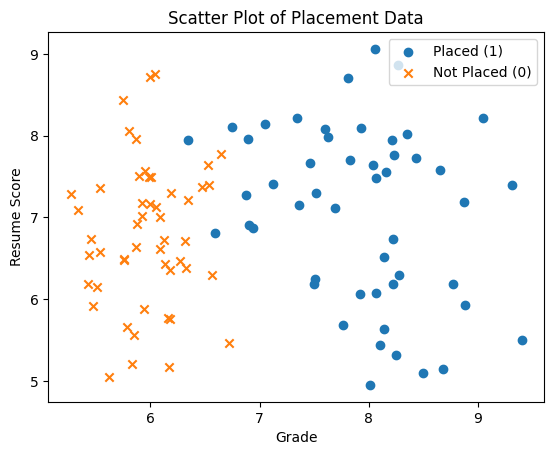

In [ ]:
# Separate classes
placed = df[df["placed"] == 1] # You split data into two groups: placed = 1, not placed = 0
not_placed = df[df["placed"] == 0]

# Scatter Plot (Visualization)
plt.scatter(placed["grade"], placed["resume_score"], label="Placed (1)", marker='o')
plt.scatter(not_placed["grade"], not_placed["resume_score"], label="Not Placed (0)", marker='x')

# Labels
plt.xlabel("Grade")
plt.ylabel("Resume Score")
plt.title("Scatter Plot of Placement Data")

# Legend
plt.legend()

# Show plot
plt.show()

In [ ]:
# Model (Perceptron)
class Perceptron(nn.Module): # defining a neural network class
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1) # Input size = 2 (cgpa, resume_score), Output = 1 (probability of placement), Mathematically: 𝑧=𝑤1𝑥1 + 𝑤2𝑥2 + 𝑏
                                        
    def forward(self, x):
        return self.linear(x)  # raw score (logits), NOT probability yet

model = Perceptron()

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss() # Best loss for binary classification (sigmoid + binary cross entropy)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # SGD = updates weights step by step

# Training
epochs = 200

for epoch in range(epochs): # Each epoch = one full pass over dataset
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor) # Model predicts → compare with true labels

    optimizer.zero_grad()  # This is the core of deep learning: 
    loss.backward()   # loss.backward() → compute gradients
    optimizer.step()  # optimizer.step() → update weights

# Extract weights → These define your decision boundary
weights = model.linear.weight.detach().numpy()[0]
bias = model.linear.bias.detach().numpy()[0]  

print("Weights:", weights)
print("Bias:", bias)

Weights: [ 0.60530126 -0.580254  ]
Bias: 0.012600633


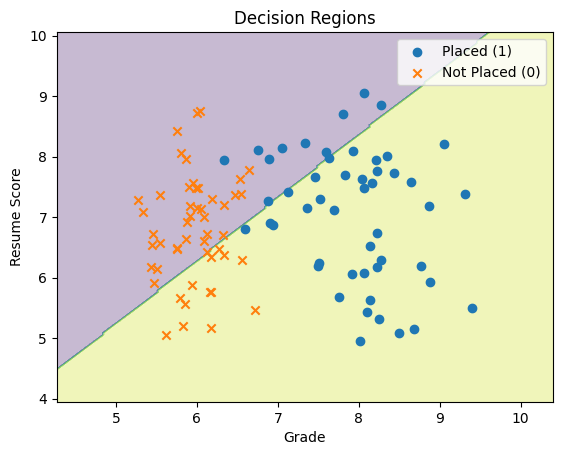

In [ ]:
# -----------------------------------
# Decision Boundary Plot 
# -----------------------------------

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Creates a 2D space of possible inputs
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Flatten grid for prediction
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict (For every point: Predict class (0 or 1))
with torch.no_grad():
    logits = model(grid_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float().numpy()

Z = preds.reshape(xx.shape)  # Convert predictions back to grid shape

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Scatter plot
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Placed (1)", marker='o')
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Not Placed (0)", marker='x')

plt.xlabel("Grade")
plt.ylabel("Resume Score")
plt.title("Decision Regions")
plt.legend()

plt.show()